# Aurora Fine-Tuning + Rollout (Config-Driven)

This notebook provides an end-to-end **supervised fine-tuning + rollout** workflow for Aurora,
including **regional/non-global domains** and configurable predictor/target variables.

Workflow stages:
1. Load YAML config
2. Optionally apply local notebook overrides
3. Open and subset train/val/test datasets
4. Build Aurora batches from predictor variables and lead-time targets
5. Configure frozen-backbone or full-model fine-tuning
6. Train + validate + checkpoint (`best.ckpt`, `last.ckpt`)
7. Run rollout from the fine-tuned model
8. Save predictions/diagnostics (NetCDF, history CSV/JSON, manifest)

## Environment / Imports

In [1]:
# Setup: Add project root to Python path
import os
import sys
from pathlib import Path

os.environ.setdefault('HF_HUB_DISABLE_PROGRESS_BARS', '1')

# Get the project root (parent of finetune directory)
notebook_dir = Path.cwd()
if notebook_dir.name == 'finetune':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: /data/aurora


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr

import finetune.aurora_finetune_utils as ft
from aurora import (
    Aurora,
    Aurora12hPretrained,
    AuroraAirPollution,
    AuroraHighRes,
    AuroraPretrained,
    AuroraSmallPretrained,
    AuroraWave,
)

/home/azureuser/miniforge3/envs/aurora/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load YAML Config

In [3]:
# Papermill parameter: override with `-p CONFIG_PATH_NAME ...`.
# Path resolution intentionally occurs in the next code cell, after
# Papermill injects parameter overrides.
CONFIG_PATH_NAME = 'aurora_NO2_finetune_US-WEST_3day_lead_config.yaml'


## Optional Local Override Cell (Quick Edits)

Use this cell for notebook-local experiments without editing the YAML file.

In [4]:
# Resolve the selected YAML only after Papermill parameter injection.
if Path(CONFIG_PATH_NAME).exists():
    CONFIG_PATH = Path(CONFIG_PATH_NAME)
elif (Path('finetune') / CONFIG_PATH_NAME).exists():
    CONFIG_PATH = Path('finetune') / CONFIG_PATH_NAME
else:
    raise FileNotFoundError(f'Config file {CONFIG_PATH_NAME} not found')
print(f'Using config: {CONFIG_PATH.resolve()}')

LOCAL_OVERRIDES = {
    # Example:
    # 'training': {'num_epochs': 1, 'batch_size': 2},
    # 'model': {'backbone_freeze': False, 'trainable_head_only': False},
    # 'rollout': {'rollout_num_steps': 4},
}

Using config: /data/aurora/finetune/aurora_NO2_finetune_US-WEST_3day_lead_config.yaml


In [5]:
cfg = ft.load_config(CONFIG_PATH, overrides=LOCAL_OVERRIDES)
print(json.dumps(cfg, indent=2)[:4000])

{
  "paths": {
    "project_root": "/data/aurora/finetune",
    "data_dir": "/data/aurora/data",
    "train_data_path": "/data/aurora/data/NO2_US-WEST_3day_lead/train.nc",
    "val_data_path": "/data/aurora/data/NO2_US-WEST_3day_lead/test.nc",
    "test_data_path": "/data/aurora/data/NO2_US-WEST_3day_lead/test.nc",
    "output_dir": "/data/aurora/finetune/outputs/NO2_US-WEST_3day_lead",
    "checkpoint_dir": "/data/aurora/finetune/outputs/checkpoints/NO2_US-WEST_3day_lead",
    "pretrained_checkpoint": "",
    "static_data_path": "/data/cams/aurora-0.4-air-pollution-static.pickle",
    "optional_resume_checkpoint": "",
    "case_data_dir": "/data/aurora/data/NO2_US-WEST_3day_lead"
  },
  "case_name": "NO2_US-WEST_3day_lead",
  "data": {
    "predictor_variables": [
      {
        "dataset_name": "t2m",
        "aurora_name": "2t",
        "kind": "surf"
      },
      {
        "dataset_name": "u10",
        "aurora_name": "10u",
        "kind": "surf"
      },
      {
        "datase

## Data Loading for Predictors and Targets

In [6]:
print(f"Train data: {cfg['paths']['train_data_path']}")
print(f"Validation data: {cfg['paths'].get('val_data_path', 'None (skipped)')}")
print(f"Test data: {cfg['paths']['test_data_path']}")

train_ds = ft.open_dataset(cfg['paths']['train_data_path'], cfg)
val_ds = None
if cfg['paths'].get('val_data_path'):
    val_ds = ft.open_dataset(cfg['paths']['val_data_path'], cfg)
test_ds = ft.open_dataset(cfg['paths']['test_data_path'], cfg)

# Merge static variables from external pickle (lsm, z, slt) into each dataset.
static_path = cfg['paths'].get('static_data_path', '')
if static_path:
    train_ds = ft.merge_external_static_vars(train_ds, static_path, cfg)
    if val_ds is not None:
        val_ds = ft.merge_external_static_vars(val_ds, static_path, cfg)
    test_ds = ft.merge_external_static_vars(test_ds, static_path, cfg)
    print(f'Merged static vars from: {static_path}')

resolved_specs = ft.resolve_variable_specs(train_ds, cfg)
_longitude_datasets = [train_ds, test_ds] + ([] if val_ds is None else [val_ds])
lon_periodic = ft.validate_longitude_consistency(_longitude_datasets, cfg)
lon_dim = str(cfg.get('data', {}).get('lon_dim', 'longitude'))
model_longitude = train_ds[lon_dim].values

print('Train:', train_ds.sizes)
print('Val:  ', val_ds.sizes if val_ds is not None else '(skipped)')
print('Test: ', test_ds.sizes)
print('Predictors:', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.predictors])
print('Targets:   ', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.targets])
print('Static:    ', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.static])

Train data: /data/aurora/data/NO2_US-WEST_3day_lead/train.nc
Validation data: /data/aurora/data/NO2_US-WEST_3day_lead/test.nc
Test data: /data/aurora/data/NO2_US-WEST_3day_lead/test.nc
Merged static vars from: /data/cams/aurora-0.4-air-pollution-static.pickle
Train: Frozen({'time': 732, 'latitude': 53, 'longitude': 70, 'level': 13})
Val:   Frozen({'time': 185, 'latitude': 53, 'longitude': 70, 'level': 13})
Test:  Frozen({'time': 185, 'latitude': 53, 'longitude': 70, 'level': 13})
Predictors: ['t2m->2t (surf)', 'u10->10u (surf)', 'v10->10v (surf)', 'msl->msl (surf)', 'tcno2->tcno2 (surf)', 'z->z (atmos)', 'u->u (atmos)', 'v->v (atmos)', 't->t (atmos)', 'q->q (atmos)', 'no2->no2 (atmos)']
Targets:    ['no2->no2 (atmos)', 'tcno2->tcno2 (surf)']
Static:     ['lsm->lsm (static)', 'z_static->z (static)', 'slt->slt (static)', 'static_ammonia->static_ammonia (static)', 'static_ammonia_log->static_ammonia_log (static)', 'static_co->static_co (static)', 'static_co_log->static_co_log (static)', '

## Regional Domain Handling

In [7]:
lat_dim = cfg['data'].get('lat_dim', 'latitude')
lon_dim = cfg['data'].get('lon_dim', 'longitude')

print('Domain type:', cfg['data'].get('domain_type', 'global'))
print('Latitude range:', float(train_ds[lat_dim].values.max()), 'to', float(train_ds[lat_dim].values.min()))
print('Longitude range:', float(train_ds[lon_dim].values.min()), 'to', float(train_ds[lon_dim].values.max()))
print('Grid shape:', train_ds.sizes[lat_dim], 'x', train_ds.sizes[lon_dim])

Domain type: regional
Latitude range: 51.99999999999968 to 31.199999999999754
Longitude range: 232.00000000000222 to 259.60000000000235
Grid shape: 53 x 70


## Batch Construction for Aurora


In [8]:
train_samples = ft.build_training_samples(train_ds, cfg, split_name='train')
val_samples = ft.build_training_samples(val_ds, cfg, split_name='val') if val_ds is not None else []

# Test set has only 2 time steps (enough for rollout start, not for supervised samples).
# Build a rollout-start sample manually: history = [0, 1], no targets needed.
input_steps = int(cfg['data'].get('input_time_steps', 2))
test_samples = [{
    'anchor_index': input_steps - 1,
    'history_indices': list(range(input_steps)),
    'target_indices': {},
}]

print('Num train samples:', len(train_samples))
print('Num val samples:  ', len(val_samples) if val_samples else '(skipped)')
print('Num test samples (rollout start):', len(test_samples))

quick_idx = int(cfg.get('notebook', {}).get('quicklook_sample_index', 0))
quick_idx = max(0, min(quick_idx, len(train_samples) - 1))
quick_batch = ft.build_aurora_batch(train_ds, train_samples[quick_idx], cfg, resolved_specs)

print('Quick batch spatial shape:', quick_batch.spatial_shape)
print('Quick batch time:', quick_batch.metadata.time)
print('Quick batch levels:', quick_batch.metadata.atmos_levels)

Num train samples: 725
Num val samples:   178
Num test samples (rollout start): 1
Quick batch spatial shape: torch.Size([51, 69])
Quick batch time: (datetime.datetime(2023, 7, 1, 12, 0),)
Quick batch levels: (50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 400.0, 500.0, 600.0, 700.0, 850.0, 925.0, 1000.0)


## Model Initialization

In [9]:
# ── Distributed Training ───────────────────────────────────
# Launch training across all idle GPUs using the distributed script.
# This avoids OOM by: (1) storing params in bf16, and (2) sharding data
# across multiple GPUs with manual gradient all-reduce.

import os, subprocess, sys, gc, html, re
from IPython.display import HTML, display

# notebook.verbosity controls only this child-process display:
#   0 = completion/failure status only; 1 = progress + meaningful messages;
#   2 = the complete child-process log (including routine setup details).
_notebook_verbosity = int(cfg.get('notebook', {}).get('verbosity', 1))
if _notebook_verbosity not in {0, 1, 2}:
    raise ValueError('notebook.verbosity must be 0, 1, or 2')

# Release any GPU memory held by this notebook kernel before launching.
if torch.cuda.is_available():
    gc.collect()
    torch.cuda.empty_cache()

# Locate the distributed script relative to this notebook.
_nb_dir = Path('.').resolve()
_project_root = _nb_dir.parent if _nb_dir.name == 'finetune' else _nb_dir
for _candidate in [
    _nb_dir / 'aurora_finetune_distributed.py',
    _nb_dir / 'finetune' / 'aurora_finetune_distributed.py',
]:
    if _candidate.exists():
        dist_script = str(_candidate)
        break
else:
    raise FileNotFoundError('Cannot find aurora_finetune_distributed.py')

# Resolve the Python executable. Prefer an explicit AURORA_PYTHON override,
# then the current kernel if it can import this project, then known local envs.
def _python_can_import_aurora(python_exe):
    try:
        probe = subprocess.run(
            [python_exe, '-c', 'import torch; import aurora; import finetune.aurora_finetune_utils'],
            cwd=str(_project_root), text=True, capture_output=True, timeout=30,
        )
    except Exception as exc:
        return False, str(exc)
    return probe.returncode == 0, (probe.stderr or probe.stdout).strip()

_candidate_pythons = [
    os.environ.get('AURORA_PYTHON', ''),
    sys.executable,
    '/home/azureuser/miniforge3/envs/aurora/bin/python',
    '/mnt/data2/kyo/mamba/envs/Aurora/bin/python',
]
_aurora_py = None
_python_probe_errors = []
for _candidate_py in _candidate_pythons:
    if not _candidate_py:
        continue
    _candidate_py = str(Path(_candidate_py).expanduser())
    if not Path(_candidate_py).exists():
        _python_probe_errors.append(f'{_candidate_py}: not found')
        continue
    _ok, _err = _python_can_import_aurora(_candidate_py)
    if _ok:
        _aurora_py = _candidate_py
        break
    _python_probe_errors.append(f'{_candidate_py}: {_err.splitlines()[-1] if _err else "import failed"}')
if _aurora_py is None:
    raise RuntimeError(
        'Could not find a Python environment that imports torch/aurora/finetune. '
        'Set AURORA_PYTHON=/path/to/env/bin/python. Tried:\n  - '
        + '\n  - '.join(_python_probe_errors)
    )
cmd = [_aurora_py, dist_script, '--config', str(CONFIG_PATH.resolve())]
# Optionally specify GPUs: cmd += ['--gpus', '5,6,7']

if _notebook_verbosity >= 2:
    print(f'Using Python: {_aurora_py}')
    print(f'Launching: {" ".join(cmd)}')
    print('=' * 60, flush=True)
elif _notebook_verbosity >= 1:
    print('Distributed training started (routine setup messages suppressed).', flush=True)

env = os.environ.copy()
env.setdefault('HF_HUB_DISABLE_PROGRESS_BARS', '1')  # keep HF *download* bars quiet
# Enable the training/validation tqdm bars. Explicitly clear any disable flags
# that may have been inherited from this kernel's environment, otherwise the
# child process silences its progress bars (see _progress_bars_disabled()).
env['TQDM_DISABLE'] = '0'
env['AURORA_DISABLE_PROGRESS_BARS'] = '0'
env['PYTHONUNBUFFERED'] = '1'

# Stream the child's stdout+stderr live. Jupyter often renders carriage-return
# tqdm updates as new output lines, so keep tqdm's current line in one display
# slot and print newline-terminated logs normally.
proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # merge streams to preserve ordering
    bufsize=0,
    env=env,
)

_ansi_re = re.compile(r'\x1b\[[0-9;?]*[ -/]*[@-~]')
_progress_display = (
    display(HTML('<pre style="margin:0"></pre>'), display_id=True)
    if _notebook_verbosity >= 1 else None
)
_stream_line = ['']
_routine_output_prefixes = (
    'Launching on ',
    'Longitude grid:',
    'Norm stats:',
    'Validation source:',
    'Train samples:',
    'Loading default HF checkpoint',
    'Flow-refine head active:',
    'Parameters:',
    'Params kept in fp32;',
    'GPU memory after model load:',
    '[Gloo] Rank ',
    'World size:',
    '[opt] ',
    '[NEW] bucket=',
    '[pre] bucket=',
    'self.gen = func(*args, **kwds)',
)

def _clean_output_line(text):
    return _ansi_re.sub('', text).rstrip()

def _looks_like_progress(text):
    clean = _clean_output_line(text)
    return bool(clean) and ('%' in clean or 'batch/s' in clean or 'it/s' in clean) and '|' in clean

def _suppress_child_line(text):
    clean = _clean_output_line(text).strip()
    if _notebook_verbosity == 0:
        return True
    return _notebook_verbosity < 2 and clean.startswith(_routine_output_prefixes)

def _show_progress(text):
    clean = _clean_output_line(text)
    if clean and _progress_display is not None:
        _progress_display.update(HTML(f'<pre style="margin:0">{html.escape(clean)}</pre>'))

def _emit_child_line(text):
    if _looks_like_progress(text):
        if _notebook_verbosity >= 1:
            _show_progress(text)
    elif not _suppress_child_line(text):
        print(_clean_output_line(text))

def _write_child_text(text):
    for ch in text:
        if ch == '\r':
            if _stream_line[0]:
                _emit_child_line(_stream_line[0])
                _stream_line[0] = ''
        elif ch == '\n':
            if _stream_line[0]:
                _emit_child_line(_stream_line[0])
                _stream_line[0] = ''
            elif _notebook_verbosity >= 2:
                print()
        else:
            _stream_line[0] += ch
    sys.stdout.flush()

_fd = proc.stdout.fileno()
_output_tail = ''
while True:
    chunk = os.read(_fd, 4096)
    if not chunk:
        break
    _decoded = chunk.decode('utf-8', errors='replace')
    _output_tail = (_output_tail + _decoded)[-12000:]
    _write_child_text(_decoded)
if _stream_line[0]:
    _emit_child_line(_stream_line[0])
    _stream_line[0] = ''

rc = proc.wait()

if _notebook_verbosity >= 2:
    print()
    print('=' * 60)
if rc != 0:
    raise RuntimeError(
        f'Distributed training failed (exit {rc}). '
        f'If GPUs are occupied by stale processes, restart the notebook kernel first.\n\n'
        f'Last child-process output:\n{_output_tail}'
    )
print('Distributed training completed successfully.')


Distributed training started (routine setup messages suppressed).


Mamba temporal module active: 10,786 params (surf=['tcno2'], atmos=['no2'])







































  [flow] epoch 33: sampling_steps 1 -> 8 (switch at epoch 33)

















































































Post-training rollout checkpoint: /data/aurora/finetune/outputs/checkpoints/NO2_US-WEST_3day_lead/best.ckpt
Rollout prediction steps: 6
Saved rollout NetCDF: /data/aurora/finetune/outputs/NO2_US-WEST_3day_lead/rollout_predictions.nc
Training complete.
Distributed training completed successfully.


## Freeze / Unfreeze Configuration

In [10]:
# ── Load results from distributed training ─────────────────────────
import subprocess as _sp

model_cfg = cfg['model']
train_cfg = cfg['training']
checkpoint_dir = Path(cfg['paths']['checkpoint_dir'])
output_dir = Path(cfg['paths']['output_dir'])
best_ckpt_path = checkpoint_dir / 'best.ckpt'
last_ckpt_path = checkpoint_dir / 'last.ckpt'

# Pick the idle GPU with the most free memory using nvidia-smi
# (avoids creating CUDA contexts on busy GPUs which itself can OOM).
def _pick_best_gpu():
    try:
        out = _sp.check_output(
            ['nvidia-smi', '--query-gpu=index,memory.free',
             '--format=csv,noheader,nounits'], text=True)
    except Exception:
        return 0
    best_idx, best_free = 0, 0
    for line in out.strip().splitlines():
        parts = line.split(',')
        idx, free = int(parts[0]), float(parts[1])
        if free > best_free:
            best_idx, best_free = idx, free
    print(f'Auto-selected GPU {best_idx} ({best_free/1024:.1f} GB free)')
    return best_idx

device = torch.device(f'cuda:{_pick_best_gpu()}')

# Reconstruct model (lightweight — on CPU first)
variant = str(model_cfg.get('model_variant', 'aurora_pretrained')).lower()
MODEL_REGISTRY = {
    'aurora': Aurora, 'aurora_pretrained': AuroraPretrained,
    'aurora_small_pretrained': AuroraSmallPretrained,
    'aurora_12h_pretrained': Aurora12hPretrained,
    'aurora_highres': AuroraHighRes, 'aurora_air_pollution': AuroraAirPollution,
    'aurora_wave': AuroraWave,
}
model_var_cfg = ft.derive_model_variable_config(resolved_specs, cfg)
model_kwargs = dict(model_cfg.get('model_kwargs', {}))
if 'patch_size' in model_cfg and 'patch_size' not in model_kwargs:
    model_kwargs['patch_size'] = int(model_cfg['patch_size'])
model_kwargs['autocast'] = False

model = MODEL_REGISTRY[variant](
    surf_vars=model_var_cfg['surf_vars'],
    static_vars=model_var_cfg['static_vars'],
    atmos_vars=model_var_cfg['atmos_vars'],
    **model_kwargs,
)

# Wrap with conv_refine / flow_refine if enabled (must match training architecture).
model = ft.maybe_wrap_conv_refine(model, cfg, resolved_specs, lon=model_longitude)
model = ft.maybe_wrap_flow_refine(model, cfg, resolved_specs, lon=model_longitude)

# Select only a validated best checkpoint from the latest training run;
# this refuses a stale best.ckpt left by an older run.
ckpt_to_load = ft.select_refinement_checkpoint(
    checkpoint_dir,
    require_validated=bool(cfg.get('inference', {}).get('require_validated_checkpoint', False)),
)
if ckpt_to_load.exists():
    state = torch.load(str(ckpt_to_load), map_location='cpu', weights_only=False)
    ft.validate_checkpoint_longitude(model, state)
    ft.validate_checkpoint_refinement_contract(model, state, cfg, resolved_specs)
    # Flow-refine wrapper needs norm stats for de-normalisation at inference.
    from finetune.flow_refine import AuroraFlowRefine as _AFR
    if isinstance(model, _AFR):
        _ns = state.get('norm_stats')
        if _ns is None:
            raise ValueError('Flow-refine checkpoint is missing norm_stats; refusing unsafe rollout.')
        model.set_norm_stats(_ns)
        print(f'Set flow-refine norm stats: {list(_ns.keys())}')
    model.load_state_dict(state['model_state_dict'])
    print(f'Loaded checkpoint: {ckpt_to_load}')
    print(f'  epoch={state.get("epoch")}, step={state.get("global_step")}, '
          f'best_val_loss={state.get("best_val_loss", "n/a")}')
else:
    print('WARNING: No checkpoint found — using untrained model')

mixed_precision_mode = str(model_cfg.get('mixed_precision', 'none')).lower()
use_bf16 = mixed_precision_mode in {'bf16', 'bfloat16'}
if use_bf16:
    model = model.to(dtype=torch.bfloat16)
model = model.to(device)
model.eval()

param_summary = ft.configure_trainable_parameters(model, cfg)
print(f'Model on {device}, params: {json.dumps(param_summary)}')

Auto-selected GPU 0 (93.1 GB free)
Set flow-refine norm stats: ['no2', 'tcno2']
Loaded checkpoint: /data/aurora/finetune/outputs/checkpoints/NO2_US-WEST_3day_lead/best.ckpt
  epoch=59, step=43500, best_val_loss=0.00012685178080573678
Model on cuda:0, params: {"total_parameters": 1275972916, "trainable_parameters": 23647028, "frozen_parameters": 1252325888}


## Fine-Tuning Loop

In [11]:
# ── Load training history ──────────────────────────────────────────
history_path = output_dir / 'training_history.json'
if history_path.exists():
    history = json.loads(history_path.read_text())
    print(f'Loaded {len(history)} history rows')
else:
    # Try CSV fallback
    history_csv = output_dir / 'training_history.csv'
    if history_csv.exists():
        import csv
        with open(history_csv) as f:
            history = list(csv.DictReader(f))
            for h in history:
                for k in h:
                    try: h[k] = float(h[k])
                    except (ValueError, TypeError): pass
        print(f'Loaded {len(history)} history rows from CSV')
    else:
        history = []
        print('No training history file found')


Loaded 100 history rows


## Validation


In [12]:
if history:
    print('Best validation loss:', float(np.nanmin([h['val_loss'] for h in history])))
    print('Final epoch record:', history[-1])
else:
    print('No history rows were recorded.')

Best validation loss: 0.00012623993097804487
Final epoch record: {'epoch': 99, 'global_step': 72500, 'train_loss': 0.008756398223340511, 'val_loss': 0.00012655751197598875, 'baseline_val_loss': 0.0012827400350943208, 'val_improvement_percent': 90.13381445082261, 'lr': 3.76081317272679e-06}


## Loss vs Epochs Plot

✓ Saved loss plot: /data/aurora/finetune/outputs/NO2_US-WEST_3day_lead/loss_vs_epochs.png


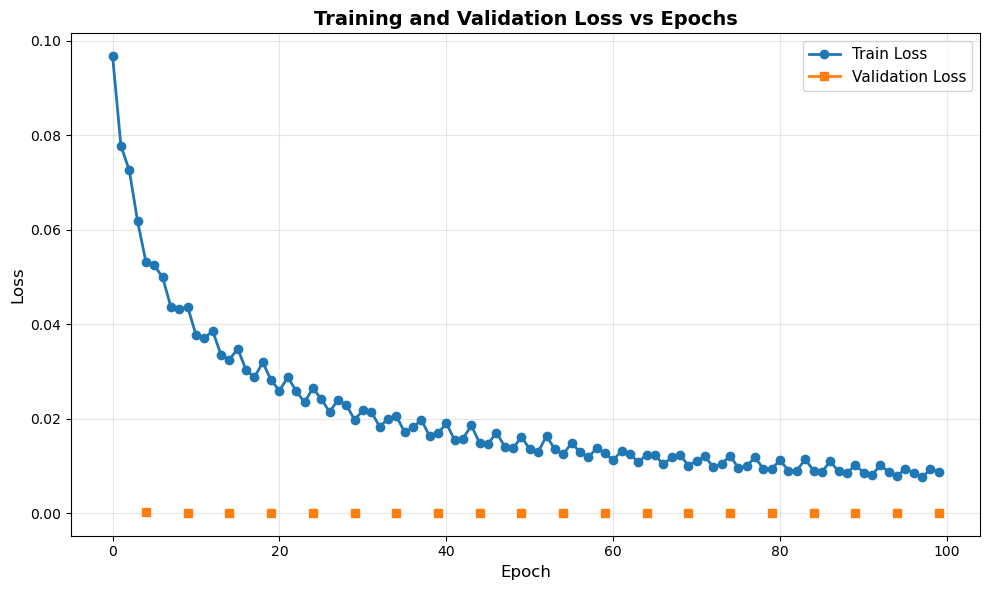

In [13]:
# Plot Training and Validation Loss
if history:
    epochs = [h['epoch'] for h in history]
    train_losses = [h['train_loss'] for h in history]
    val_losses = [h['val_loss'] for h in history]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2, markersize=6)
    ax.plot(epochs, val_losses, 's-', label='Validation Loss', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training and Validation Loss vs Epochs', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    loss_plot_path = output_dir / 'loss_vs_epochs.png'
    fig.savefig(loss_plot_path, dpi=150)
    print(f'✓ Saved loss plot: {loss_plot_path}')
    plt.show()
else:
    print('No training history to plot.')

## Checkpoint Saving


In [14]:
print('Best checkpoint:', best_ckpt_path, '| exists:', best_ckpt_path.exists())
print('Last checkpoint:', last_ckpt_path, '| exists:', last_ckpt_path.exists())


Best checkpoint: /data/aurora/finetune/outputs/checkpoints/NO2_US-WEST_3day_lead/best.ckpt | exists: True
Last checkpoint: /data/aurora/finetune/outputs/checkpoints/NO2_US-WEST_3day_lead/last.ckpt | exists: True


## Rollout Inference from Fine-Tuned Model

In [15]:
# -- Inference commented out -- use aurora_inference_rollout.ipynb instead --
# rollout_cfg = cfg['rollout']
# predictions = []
#
# if bool(rollout_cfg.get('run_rollout_after_training', True)):
#     if not test_samples:
#         raise ValueError('No test samples available for rollout.')
#
#     rollout_idx = int(cfg.get('notebook', {}).get('quicklook_sample_index', 0))
#     rollout_idx = max(0, min(rollout_idx, len(test_samples) - 1))
#
#     model.eval()
#     predictions = ft.run_rollout(
#         model=model,
#         ds=test_ds,
#         start_sample=test_samples[rollout_idx],
#         config=cfg,
#         resolved_specs=resolved_specs,
#         device=device,
#     )
#
# # Convert bf16 predictions to fp32 for numpy/netCDF compatibility.
# predictions = [p.type(torch.float32) for p in predictions]
# print('Rollout prediction steps:', len(predictions))

## Output Writing and Simple Plots / Diagnostics

In [16]:
# -- Inference output/plots commented out -- use aurora_inference_rollout.ipynb instead --
# artifacts = {
#     'best_checkpoint': str(best_ckpt_path.resolve()) if best_ckpt_path.exists() else '',
#     'last_checkpoint': str(last_ckpt_path.resolve()) if last_ckpt_path.exists() else '',
# }
#
# rollout_cfg = cfg['rollout']
# output_dir = Path(cfg['paths']['output_dir'])
# rollout_path = output_dir / 'rollout_predictions.nc'
#
# rollout_ds = None
# if predictions and bool(rollout_cfg.get('save_predictions_to_netcdf', True)):
#     rollout_ds = ft.save_predictions(
#         predictions,
#         rollout_path,
#         save_netcdf=True,
#         resolved_specs=resolved_specs,
#     )
#     artifacts['rollout_netcdf'] = str(rollout_path.resolve())
#     print('Saved rollout NetCDF:', rollout_path)
#
# plot_vars = cfg.get('notebook', {}).get('plot_variables', [])
# if rollout_ds is not None and plot_vars and bool(rollout_cfg.get('save_plots', True)):
#     var = str(plot_vars[0])
#
#     fig, ax = plt.subplots(figsize=(8, 4))
#     if var in rollout_ds:
#         da = rollout_ds[var]
#         if 'level' in da.dims:
#             image = da.isel(step=0, batch=0, level=0)
#             title = f'{var} | step=0 | level=0'
#         else:
#             image = da.isel(step=0, batch=0)
#             title = f'{var} | step=0'
#     else:
#         image = None
#         title = f'Variable {var!r} not found in rollout outputs.'
#
#     if image is not None:
#         mesh = ax.imshow(image.values, origin='upper')
#         fig.colorbar(mesh, ax=ax, shrink=0.8)
#         ax.set_title(title)
#         ax.set_xlabel('longitude index')
#         ax.set_ylabel('latitude index')
#
#         fig_path = output_dir / f'quicklook_{var}.png'
#         fig.tight_layout()
#         fig.savefig(fig_path, dpi=150)
#         artifacts['quicklook_figure'] = str(fig_path.resolve())
#         print('Saved quicklook figure:', fig_path)
#     else:
#         ax.text(0.5, 0.5, title, ha='center', va='center')
#         ax.axis('off')

manifest_path = ft.write_run_manifest(
    cfg,
    output_dir,
    extras={
        'parameter_summary': param_summary,
        'num_train_samples': len(train_samples),
        'num_val_samples': len(val_samples),
        'num_test_samples': len(test_samples),
    },
)

print('Run manifest:', manifest_path)

Run manifest: /data/aurora/finetune/outputs/NO2_US-WEST_3day_lead/run_manifest.json
